### Monte Carlo and XGBoost based CVaR and NPV Portfolio Optimizer

This is a notebook that aims to extend from work done in the market risk portfolio engine notebook and the market volatility XGBoost notebook. I originally was going to make an optimizer based on my hidden markov model script. But it took me a bit to fully understand the fundamentals to even devise a script. 

Therefore, I want this aspect to reinforce what I already know in terms of discounted cash flow, but applying some of the principles I know to an aspect of optimizing a portfolio. 

In [2]:
# import necessary libraries

import numpy as np
import pandas as pd
import scipy.stats as si
from scipy.optimize import linprog
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
import xgboost as xgb
from xgboost import XGBRegressor
 
np.random.seed(42)

In [ ]:
# As before, we practice pulling data from yfinance using our favorite portfolios. 
tickers_biotech = ['LLY', 'PFE'] # eli lily and pfizer
tickers_defense = ['NOC', 'LMT','RTX','LHX'] # northrop and lockheed martin
tickers_energy = ['PLUG', 'XOM'] # lockheed martin and exxon
tickers_mixed = ['NOC', 'LMT','RTX','LHX','LLY', 'PFE'] # found I got better results when diversifying the portfolio 

tickers = tickers_mixed # we are optimizing for a defense portfolio

price_data = yf.download(tickers, start='2018-01-01', end='2026-01-01')['Close']

returns = price_data.pct_change().dropna()
log_returns = np.log(price_data / price_data.shift(1)).dropna()
 
n_assets = len(tickers)

[*********************100%***********************]  6 of 6 completed


In [29]:
# XGBoost volatility forecast, per asset 
# This employs the same set up used in the XGBoost notebook

volatility_dates = range(1, 6)
forecast_horizon = 5
 
forecasted_vols = {}
 
for ticker in tickers:
    df = pd.DataFrame()
    df['Log_Return'] = log_returns[ticker]
    df['Volatility'] = df['Log_Return'].rolling(window=21).std() * np.sqrt(252)
 
    for lag in volatility_dates:
        df[f'Lag_{lag}'] = df['Volatility'].shift(lag)
    df = df.dropna()
 
    feature_cols = [f'Lag_{lag}' for lag in volatility_dates]
    X = df[feature_cols]
    y = df['Volatility']
 
    split_idx = int(len(df) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
 
    model = XGBRegressor(n_estimators=100, learning_rate=0.25, max_depth=3)
    model.fit(X_train, y_train)
 
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
 
    live_forecast_input = df[feature_cols].tail(1)
    future_vol = model.predict(live_forecast_input)[0]
    forecasted_vols[ticker] = future_vol
 
    print(f'{ticker}: RMSE={rmse:.4f}  Forecasted Volatility={future_vol:.4f}')
 
forecasted_vol_vector = np.array([forecasted_vols[t] for t in tickers])

NOC: RMSE=0.0309  Forecasted Volatility=0.2280
LMT: RMSE=0.0298  Forecasted Volatility=0.2094
RTX: RMSE=0.0277  Forecasted Volatility=0.2330
LHX: RMSE=0.0189  Forecasted Volatility=0.2267
LLY: RMSE=0.0428  Forecasted Volatility=0.2164
PFE: RMSE=0.0177  Forecasted Volatility=0.2318


In [30]:
# Forward looking covariance 
hist_corr = returns.corr().values
D = np.diag(forecasted_vol_vector)
cov_forecast = D @ hist_corr @ D
 
mean_returns_annual = returns.mean().values*252
print(f'Mean Returns Annual: {mean_returns_annual}')

Mean Returns Annual: [0.14589321 0.38235304 0.11026011 0.13067444 0.03584509 0.17081549]


In [31]:
# Monte Carlo simulation. We are looking at 10000 scenarios as that's 
# a number that I look to look into. In reality, I can check and see if 10000 is even necessary 
# I can look at 1000 to start

num_scenarios =5000  # scenario count for the CVaR optimization (LP-sized)
scenario_returns = np.random.multivariate_normal(
    mean_returns_annual/252,  # daily mean
    cov_forecast/252,         # daily covariance
    size=num_scenarios,
)
 
confidence_level = 0.95
alpha = confidence_level

In [32]:
# Minimize CVaR directly using the Rockafellar-Uryasev linear program. 
# Here is how it works: 
#    minimize   zeta + 1/((1-alpha)*N) * sum(u_i)
#    subject to u_i >= -(w . r_i) - zeta,   u_i >= 0
#               sum(w) = 1,   0 <= w <= 1
#
#    Vars: x = [w (n), zeta (1), u (N)]

N = num_scenarios
 
c = np.concatenate([np.zeros(n_assets), [1.0], np.full(N, 1.0 / ((1 - alpha) * N))])
 
# Inequality constraints: -r_i . w - zeta - u_i <= 0
A_ub = np.zeros((N, n_assets + 1 + N))
A_ub[:, :n_assets] = -scenario_returns
A_ub[:, n_assets] = -1.0
A_ub[np.arange(N), n_assets + 1 + np.arange(N)] = -1.0
b_ub = np.zeros(N)
 
# Equality: weights sum to 1
A_eq = np.zeros((1, n_assets + 1 + N))
A_eq[0, :n_assets] = 1.0
b_eq = np.array([1.0])
 
bounds = (
    [(0.0, 1.0)] * n_assets      # long-only weights
    + [(None, None)]             # zeta unbounded
    + [(0.0, None)] * N          # u_i >= 0
)
 
lp_result = linprog(
    c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs'
)
 
cvar_weights = lp_result.x[:n_assets]
zeta = lp_result.x[n_assets]
cvar_value = lp_result.fun
 
print('\nCVaR-Minimizing Weights:')
for ticker, w in zip(tickers, cvar_weights):
    print(f'  {ticker}: {w:.4f}')
print(f'95% CVaR (daily): {cvar_value:.4f}')
 
# Drop-in line for your VaR/ES engine cells:
weights = cvar_weights


CVaR-Minimizing Weights:
  NOC: 0.1053
  LMT: 0.3328
  RTX: 0.0456
  LHX: 0.0870
  LLY: 0.2435
  PFE: 0.1857
95% CVaR (daily): 0.0188



95% 1-Day VaR ($): $1,897.65
95% 1-Day ES ($):  $2,397.73


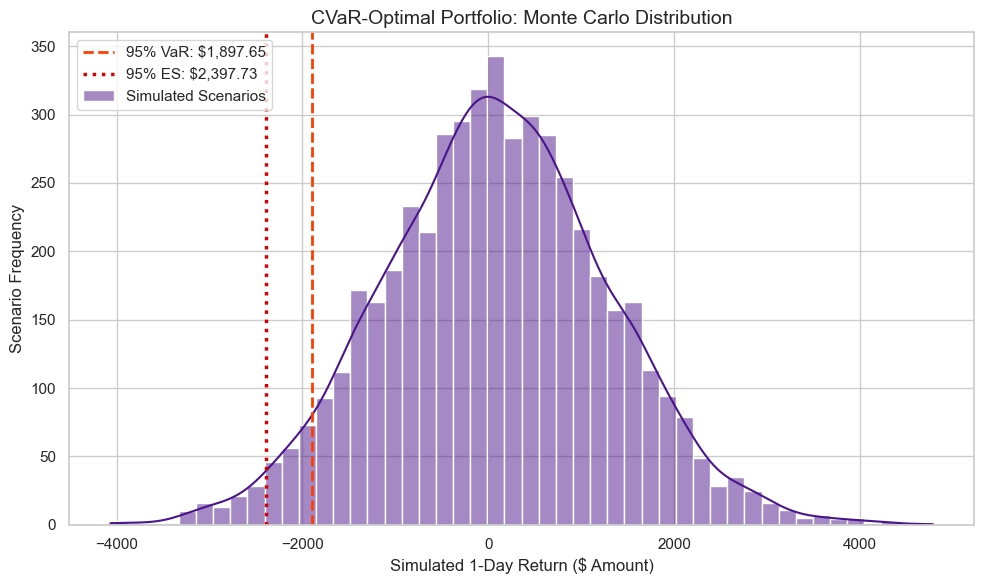

In [26]:
# Full scale Monte Carlo VaR/ES on CVaR optimized portfolio 

initial_portfolio_value = 1e5
num_simulations = int(num_scenarios)
 
sim_returns = np.random.multivariate_normal(
    mean_returns_annual / 252, cov_forecast / 252, size=num_simulations
)
sim_portfolio_returns = sim_returns @ cvar_weights
sim_portfolio_dollar_losses = initial_portfolio_value * sim_portfolio_returns
 
var_pct = np.percentile(sim_portfolio_returns, (1 - confidence_level) * 100)
var_dollar = initial_portfolio_value * var_pct
tail_losses = sim_portfolio_returns[sim_portfolio_returns <= var_pct]
es_pct = tail_losses.mean()
es_dollar = initial_portfolio_value * es_pct
 
print(f'\n95% 1-Day VaR ($): ${abs(var_dollar):,.2f}')
print(f'95% 1-Day ES ($):  ${abs(es_dollar):,.2f}')
 
sns.set_theme(style='whitegrid')
plt.figure(figsize=(10, 6))
sns.histplot(sim_portfolio_dollar_losses, kde=True, color='#4A148C', label='Simulated Scenarios')
plt.axvline(var_dollar, color='#FF3D00', linestyle='--', linewidth=2, label=f'95% VaR: ${abs(var_dollar):,.2f}')
plt.axvline(es_dollar, color='#D50000', linestyle=':', linewidth=2.5, label=f'95% ES: ${abs(es_dollar):,.2f}')
plt.title('CVaR-Optimal Portfolio: Monte Carlo Distribution', fontsize=14)
plt.xlabel('Simulated 1-Day Return ($ Amount)')
plt.ylabel('Scenario Frequency')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()
 


NPV over 5 years @ 8% discount rate:
  CVaR-Optimal Portfolio: $115,861.35
  Equal-Weight Baseline:  $87,113.05
  Delta:                  $28,748.30


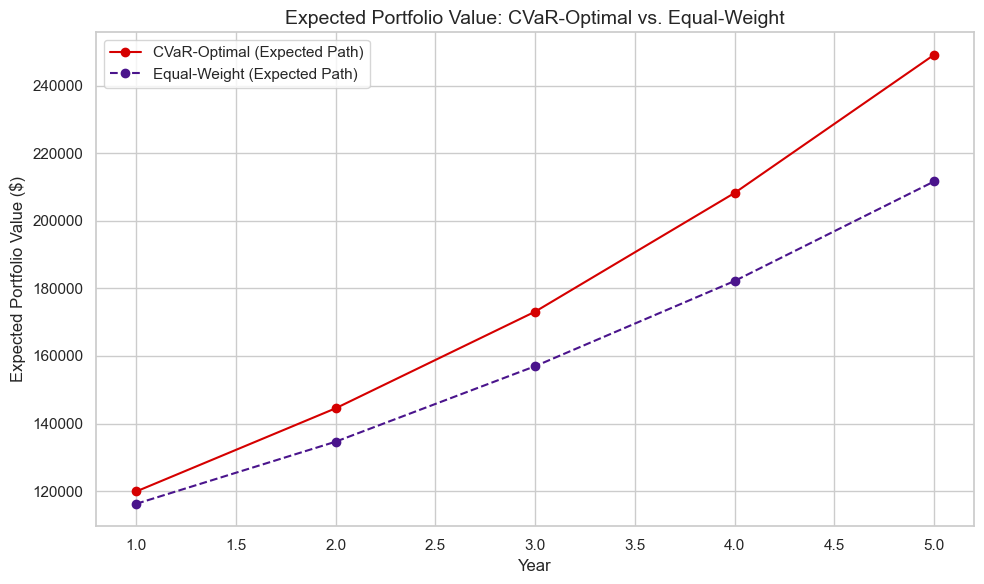

In [33]:
# Note how it is higher than the VaR and ES, which was VaR ($1,909) 
# and ES ($2,402.19) Last we do a NPV comparison 

initial_value = 1e5
elapsed_years = 5
dis_rate = 0.08 # discount rate
n_paths = 2000
 
equal_weights = np.full(n_assets, 1.0 / n_assets)
 
 
def simulate_npv(initial_portfolio_value, weights, years, discount_rate, n_paths):
    annual_returns = np.random.multivariate_normal(
        mean_returns_annual, cov_forecast, size=(n_paths, years)
    )
    portfolio_annual_returns = annual_returns @ weights  # shape (n_paths, years)
    portfolio_value_paths = initial_portfolio_value * np.cumprod(
        1 + portfolio_annual_returns, axis=1
    )
    expected_value_by_year = portfolio_value_paths.mean(axis=0)
 
    # Treat each year's incremental expected value as the cash flow,
    # discount back to present, sum for NPV. 
    cash_flows = np.diff(np.concatenate([[initial_portfolio_value], expected_value_by_year]))
    discount_factors = 1 / (1 + discount_rate) ** np.arange(1, years + 1)
    npv = -initial_portfolio_value + np.sum(cash_flows * discount_factors) + initial_portfolio_value
 
    return npv, expected_value_by_year
 
 
npv_cvar, path_cvar = simulate_npv(initial_value,cvar_weights, elapsed_years, dis_rate, n_paths)
npv_equal, path_equal = simulate_npv(initial_value,equal_weights, elapsed_years, dis_rate, n_paths)
 
print(f'\nNPV over {elapsed_years} years @ {dis_rate:.0%} discount rate:')
print(f'  CVaR-Optimal Portfolio: ${npv_cvar:,.2f}')
print(f'  Equal-Weight Baseline:  ${npv_equal:,.2f}')
print(f'  Delta:                  ${npv_cvar - npv_equal:,.2f}')
 
plt.figure(figsize=(10, 6))
plt.plot(range(1, elapsed_years + 1), path_cvar, marker='o', color='#D50000', label='CVaR-Optimal (Expected Path)')
plt.plot(range(1, elapsed_years + 1), path_equal, marker='o', color='#4A148C', linestyle='--', label='Equal-Weight (Expected Path)')
plt.title('Expected Portfolio Value: CVaR-Optimal vs. Equal-Weight', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Expected Portfolio Value ($)')
plt.legend(loc='best')
plt.tight_layout()
plt.show()